<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cement      10000 non-null  float64
 1   water       10000 non-null  float64
 2   aggregates  10000 non-null  float64
 3   strength    10000 non-null  float64
dtypes: float64(4)
memory usage: 312.6 KB

--- Summary Statistics ---
             cement         water    aggregates      strength
count  10000.000000  10000.000000  10000.000000  10000.000000
mean     299.059983    124.839677    498.945052    174.587341
std      115.467249     43.287184    171.863298     61.303010
min      100.000208     50.002721    200.178095     20.646078
25%      199.079676     87.340459    352.243950    125.844508
50%      297.815185    124.360182    497.313302    173.929215
75%      399.719619    162.571513    646.867715    224.352731
max      499.992743    199.996391    799.863467    334.652378

--- Target Variabl

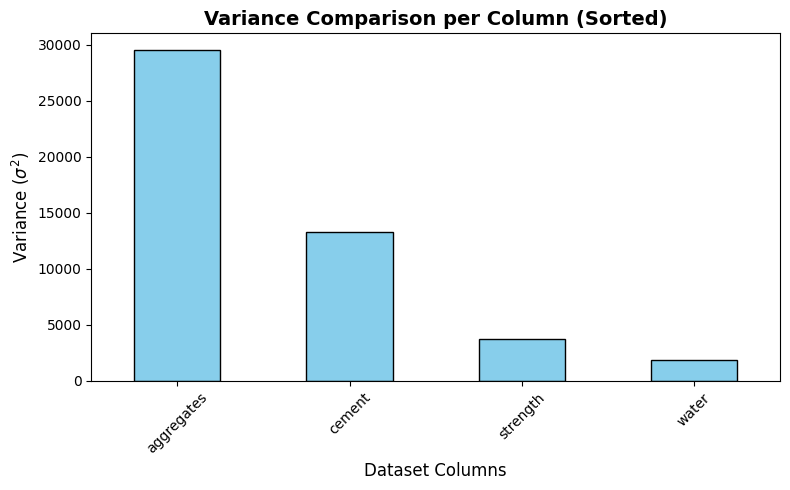

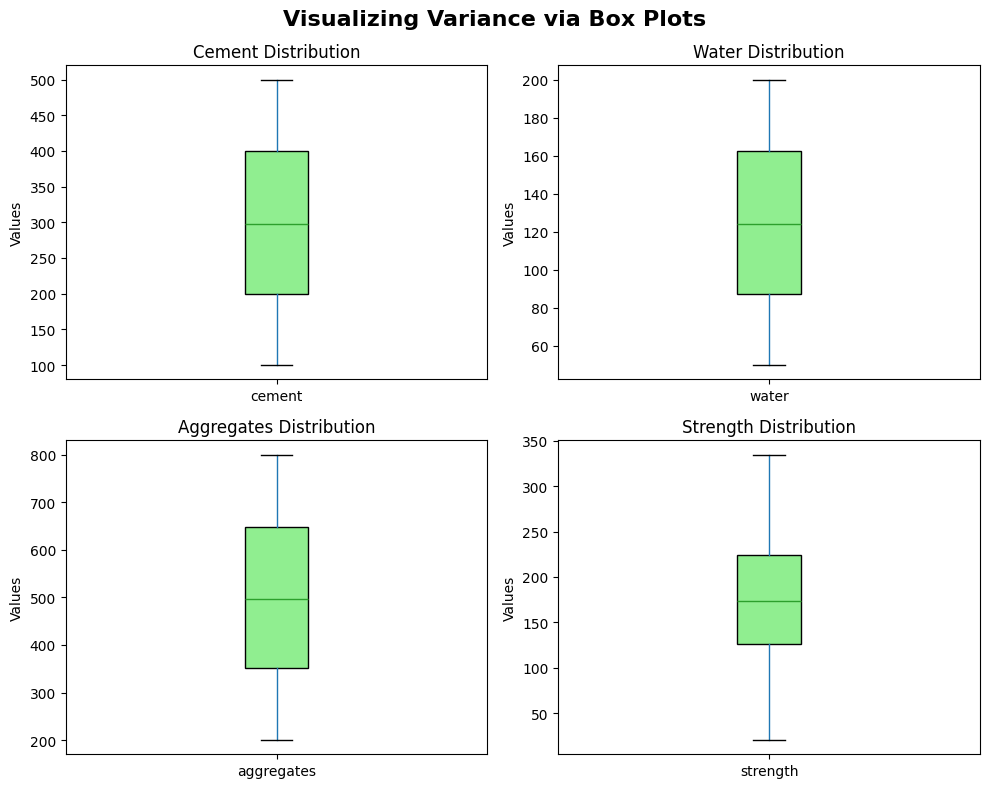

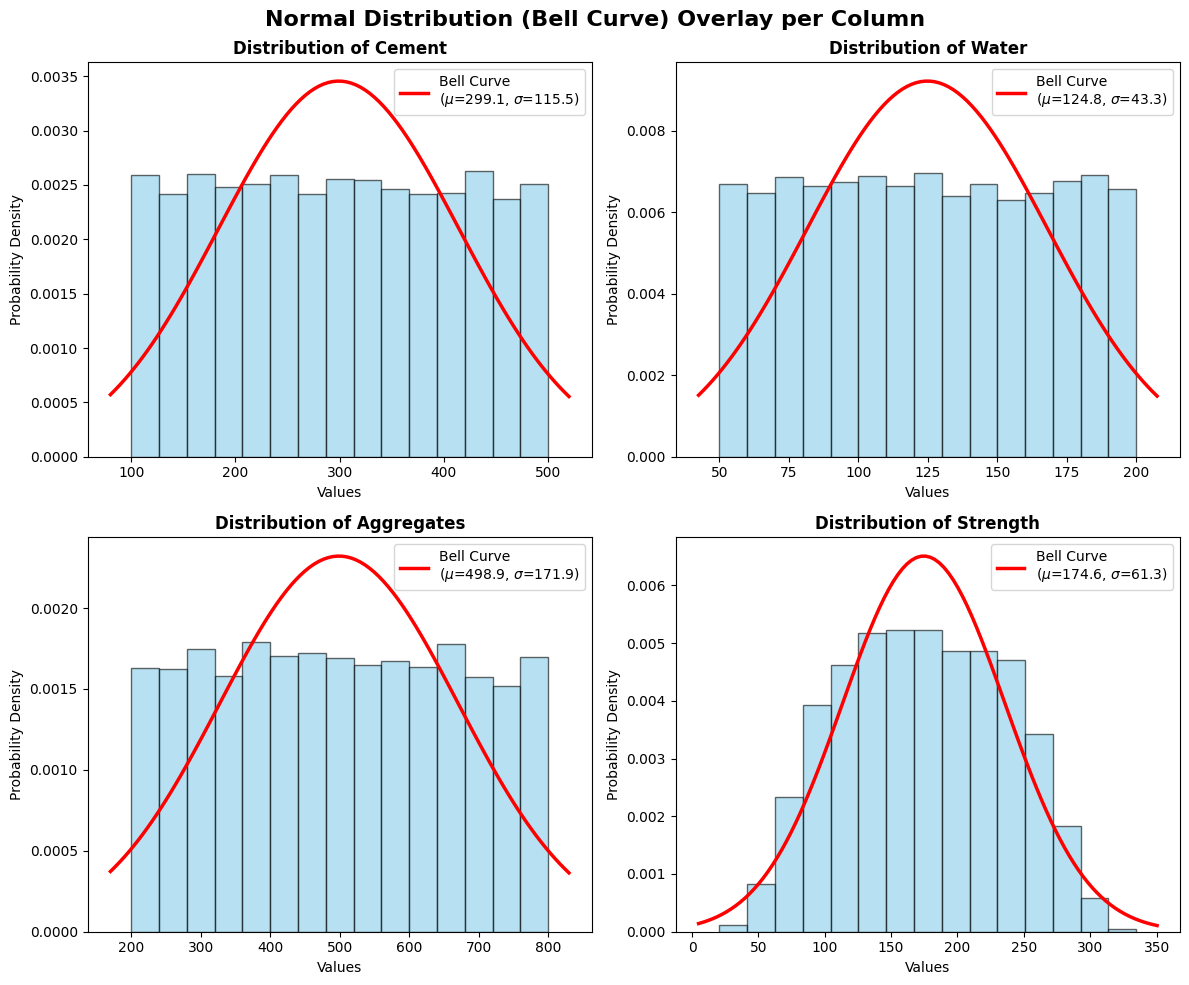

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy.stats import norm

df = pd.read_csv('civil.csv')
df.info()
print("\n--- Summary Statistics ---")
print(df.describe())

print("\n--- Target Variable ('strength') Distribution ---")
print(df['strength'].value_counts())

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

df.drop_duplicates(inplace=True)


# 2. Calculate the variance for each column and sort them
# Sorting ensures the bar chart is easy to read
variances = df.var().sort_values(ascending=False)
print("Calculated Variances:\n", variances)

# 3. PLOT 1: Bar Chart of Raw Variance Values
fig1, ax1 = plt.subplots(figsize=(8, 5))
variances.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')

ax1.set_title('Variance Comparison per Column (Sorted)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Variance ($\sigma^2$)', fontsize=12)
ax1.set_xlabel('Dataset Columns', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('variance_bar_chart.png')  # Saves the bar chart


# 4. PLOT 2: Box Plots to Visually See the Spread (Variance)
# Since scales differ wildly, subplots keep the distributions readable
fig2, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()  # Flatten the 2x2 grid to easily loop through it

for i, column in enumerate(df.columns):
    df.boxplot(column=[column], ax=axes[i], grid=False, 
               patch_artist=True, boxprops=dict(facecolor='lightgreen'))
    axes[i].set_title(f'{column.capitalize()} Distribution', fontsize=12)
    axes[i].set_ylabel('Values')

fig2.suptitle('Visualizing Variance via Box Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('variance_box_plots.png')  # Saves the box plots

# 2. Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten the 2x2 grid into a 1D array to loop easily

# 3. Loop through each column and plot the bell curve
for i, col in enumerate(df.columns):
    # Plot a density histogram of the actual data
    # 'density=True' scales the y-axis so the total area under the histogram equals 1
    axes[i].hist(df[col], bins=15, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    
    # Calculate the mean (mu) and standard deviation (std) to fit the bell curve
    mu, std = norm.fit(df[col])
    
    # Create an array of x-values ranging across the width of the plot
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    
    # Calculate the normal probability density function (the bell curve line)
    p = norm.pdf(x, mu, std)
    
    # Plot the bell curve line
    axes[i].plot(x, p, color='red', linewidth=2.5, 
                 label=f'Bell Curve\n($\mu$={mu:.1f}, $\sigma$={std:.1f})')
    
    # Style the individual subplots
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Values')
    axes[i].set_ylabel('Probability Density')
    axes[i].legend(loc='upper right')

# 4. Style the overall figure layout and save
fig.suptitle('Normal Distribution (Bell Curve) Overlay per Column', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('guassian.png')  # Saves the visualization as an image


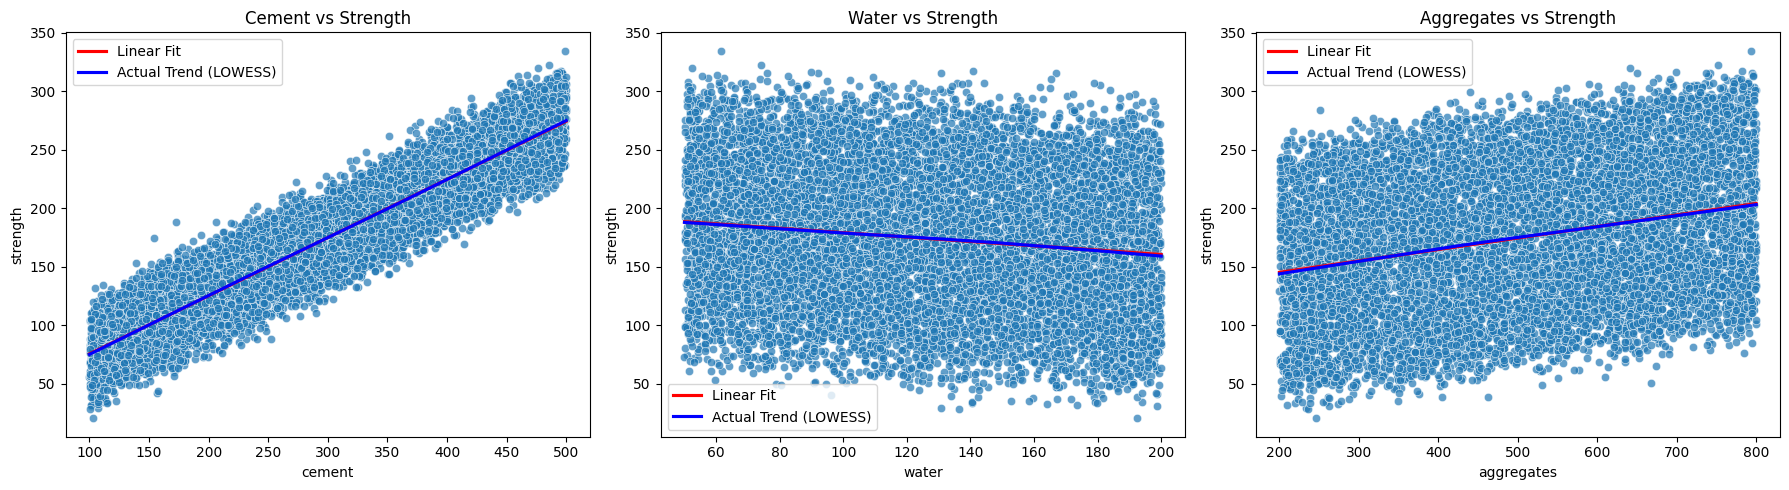

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Plot scatter plots with a linear fit vs a smoothed non-linear fit (lowess)
features = ['cement', 'water', 'aggregates']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features):
    # Plot the data points
    sns.scatterplot(data=df, x=col, y='strength', ax=axes[i], alpha=0.7)
    
    # Draw a straight linear regression line (Red)
    sns.regplot(data=df, x=col, y='strength', ax=axes[i], scatter=False, color='red', label='Linear Fit')
    
    # Draw a flexible non-linear curve (Blue) to see if it bends
    sns.regplot(data=df, x=col, y='strength', ax=axes[i], scatter=False, color='blue', lowess=True, label='Actual Trend (LOWESS)')
    
    axes[i].set_title(f'{col.capitalize()} vs Strength')
    axes[i].legend()

plt.tight_layout()
plt.show()

#If the red line (linear) and the blue line (actual trend) lie perfectly on top of each other, the relationship is linear. If the blue line noticeably curves or waves away from the straight red line, it is non-linear - here it is linear

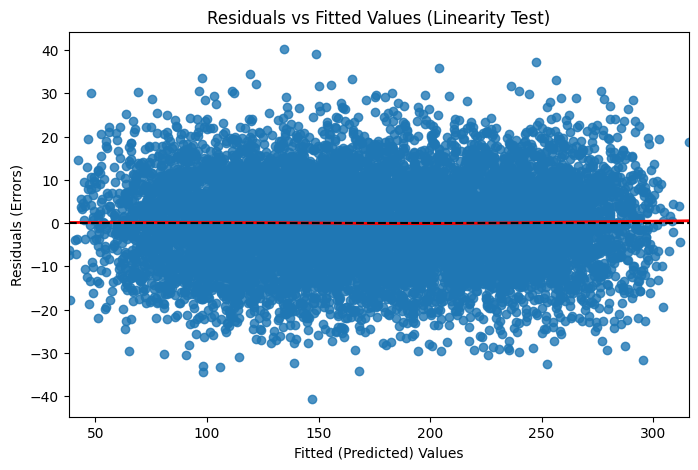

In [4]:
import statsmodels.api as sm

# Define features (X) and target (y)
X = df[['cement', 'water', 'aggregates']]
X = sm.add_constant(X)  # Adds the intercept term
y = df['strength']

# Fit linear regression model
model = sm.OLS(y, X).fit()
residuals = model.resid
fitted_values = model.fittedvalues

# Plot Residuals vs Fitted values
plt.figure(figsize=(8, 5))
sns.residplot(x=fitted_values, y=residuals, lowess=True, 
              line_kws={'color': 'red', 'lw': 2})

plt.title('Residuals vs Fitted Values (Linearity Test)')
plt.xlabel('Fitted (Predicted) Values')
plt.ylabel('Residuals (Errors)')
plt.axhline(0, color='black', linestyle='--')
plt.show()

# Linear Data: The residual points will be randomly scattered around the horizontal $y=0$ line like a cloud, and the red trend line will be perfectly flat
# Non-Linear Data: The residuals will show a distinct, recognizable pattern (like a "U" shape, a "V" shape, or an "S" curve). This means the linear model is consistently guessing too high or too low in certain ranges because it missed a curve.

# here the data is linear


In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

X_ml = df[['cement', 'water', 'aggregates']]
y_ml = df['strength']

# Evaluate Linear Regression
linear_model = LinearRegression()
linear_cv = cross_val_score(linear_model, X_ml, y_ml, cv=5, scoring='r2').mean()

# Evaluate a Non-Linear Model (Random Forest)
rf_model = RandomForestRegressor(random_state=42)
rf_cv = cross_val_score(rf_model, X_ml, y_ml, cv=5, scoring='r2').mean()

print(f"Linear Regression R² Score: {linear_cv:.3f}")
print(f"Random Forest (Non-Linear) R² Score: {rf_cv:.3f}")

if rf_cv > linear_cv + 0.1:  # If RF is significantly better
    print("Conclusion: The dataset likely has prominent Non-Linear relationships.")
else:
    print("Conclusion: A Linear model is sufficient; relationships are mostly linear.")

Linear Regression R² Score: 0.973
Random Forest (Non-Linear) R² Score: 0.968
Conclusion: A Linear model is sufficient; relationships are mostly linear.


       cement       water  aggregates
0  335.255462  153.612508  550.715080
1  243.976349  192.200723  345.942816
2  151.623525  135.493297  670.793244
3  396.217433  131.282038  247.477877
4  395.119620  175.572228  425.190884
     strength
0  201.648201
1  106.896167
2  115.278790
3  199.617536
4  201.403467
30000
10000
0.9729603743145819
0.9732266235632099
lr.coef_: [[57.6084884  -8.29623681 17.17737607]]
lr.intercept_: [174.65163906]
r2 0.9732266235632099
Mean Squared Error: 100.6081788409333
adjusted_r2 0.9731863830174632


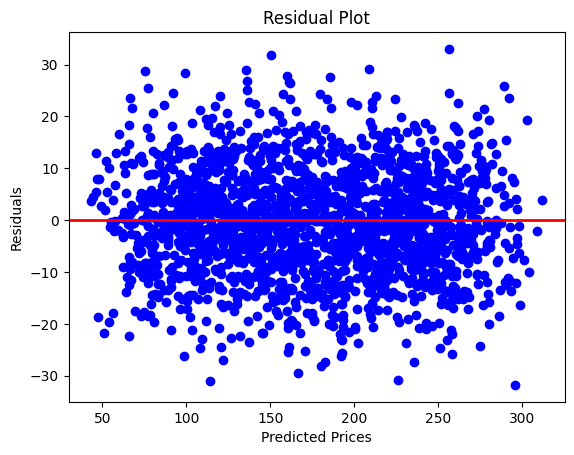

Average percentage error: 5.40%


In [15]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error


#Cap outliers
cols_to_check = ['cement', 'water', 'aggregates']
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values instead of dropping rows to preserve dataset size
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

X = df.drop(columns=['strength'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Set your new categorical column as the target
y = df[['strength']]


print(X.head())
print(y.head())

print(X.size)
print(y.size)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predict on test data
y_pred = linear_model.predict(X_test)

MLR_CoDT = linear_model.score(X_train,y_train)
print(MLR_CoDT)
MLR_CoDt = linear_model.score(X_test,y_test)
print(MLR_CoDt)
# Intercept
MLR_B0 = linear_model.intercept_
# Slope
MLR_B1 = linear_model.coef_

print("lr.coef_: {}".format(linear_model.coef_))
print("lr.intercept_: {}".format(linear_model.intercept_))

# R2
r2 = r2_score (y_test,y_pred)
print('r2',r2)
#R2(Total sum square - residual sum square / TSS)
# total variation in the target variable is the sum of squares of the differences between actual and their mean
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
n = X_test.shape[0]  # Number of samples
p = X_test.shape[1]  # Number of features
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print('adjusted_r2',adjusted_r2)

# Visualization: Residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, color="blue")
plt.axhline(y=0, color="red", linewidth=2)
plt.title("Residual Plot")
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.show()

mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Average percentage error: {mape * 100:.2f}%")

# If your average percentage error is under 5% to 10%, your model is doing a fantastic job for concrete strength prediction.

# If it is over 15%, you may need to collect more data or add more features (like concrete age, water-cement ratio, or fly ash content) to tighten up the accuracy.
#here the average is 5%, which indicates good model

In [19]:
from sklearn.linear_model import Ridge, RidgeCV

# Ridge Regression with a fixed alpha
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
print(f"Fixed Alpha - Mean Squared Error: {mse:.4f}")
print(f"Coefficients: {ridge.coef_}")

# Ridge Regression with Cross-Validation
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

# Best alpha
print(f"Best Alpha (via Cross-Validation): {ridge_cv.alpha_}")

# Predict using the best model
y_pred_cv = ridge_cv.predict(X_test)
mse_cv = mean_squared_error(y_test, y_pred_cv)
print(f"Cross-Validated Ridge - Mean Squared Error: {mse_cv:.4f}")

r2 = r2_score (y_test,y_pred)
print(f"R2 score", r2)

#R2 score of 0.97 indicates 87% data is captured


Fixed Alpha - Mean Squared Error: 100.6034
Coefficients: [57.60125012 -8.29512707 17.1751951 ]
Best Alpha (via Cross-Validation): 0.01
Cross-Validated Ridge - Mean Squared Error: 100.6081
R2 score 0.9732279042738342


In [35]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize

# --- 1. Load Data ---
# (Using the same CSV data from your previous step)
df = pd.read_csv('civil.csv')
X = df[['cement', 'water', 'aggregates']]
y = df['strength']

# Save the feature names for reuse later
FEATURE_NAMES = X.columns.tolist()

# --- 2. Train Model ---
lr_model = LinearRegression()
lr_model.fit(X, y)

# Calculate the 90th percentile
p90 = df["strength"].quantile(0.9)
print(f"90% strength that can be the target", p90) 
TARGET_STRENGTH = p90

# --- 3. Objective Function (FIXED HERE) ---
def objective_function(material_guess):
    # FIX: Convert the 1D array into a DataFrame with matching feature names
    # material_guess comes in as [cement_val, water_val, aggregate_val]
    df_guess = pd.DataFrame([material_guess], columns=FEATURE_NAMES)
    
    # Now predict without warnings
    prediction = lr_model.predict(df_guess)[0]
    
    return (prediction - TARGET_STRENGTH) ** 2


# --- 4. Optimization Setup ---
bounds = [
    (df['cement'].min(), df['cement'].max()),       
    (df['water'].min(), df['water'].max()),         
    (df['aggregates'].min(), df['aggregates'].max())  
]
initial_guess = [df['cement'].mean(), df['water'].mean(), df['aggregates'].mean()]

# --- 5. Run Optimization ---
result = minimize(objective_function, initial_guess, bounds=bounds, method='L-BFGS-B')

# --- 6. Display Results (FIXED HERE) ---
if result.success:
    optimized_mix = result.x
    print(f"--- Optimized Material Mix for {TARGET_STRENGTH} MPa ---")
    print(f"Cement required:    {optimized_mix[0]:.2f} kg")
    print(f"Water required:     {optimized_mix[1]:.2f} kg")
    print(f"Aggregate required: {optimized_mix[2]:.2f} kg")
    
    # FIX: Convert the final optimized array to a DataFrame for the verification check
    final_df = pd.DataFrame([optimized_mix], columns=FEATURE_NAMES)
    verified_strength = lr_model.predict(final_df)[0]
    
    print(f"\nVerification check -> Model predicts this mix will yield: {verified_strength:.2f} MPa")

90% strength that can be the target 256.8946885084793
--- Optimized Material Mix for 256.8946885084793 MPa ---
Cement required:    437.72 kg
Water required:     70.94 kg
Aggregate required: 526.74 kg

Verification check -> Model predicts this mix will yield: 256.89 MPa
